In [297]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, f1_score, recall_score, precision_score
import seaborn as sns
from sklearn.manifold import TSNE

Модель предсказывает, является ли аромат мужским или женским по его нотам
datasets: https://drive.google.com/drive/folders/1lUSq6XFJIGSDugBiNwOZFjPVcmOg6dzE?usp=sharing

In [298]:
df_female = pd.read_csv('parfum_dataset_female.csv')[:800]

texts_eng = df_female.iloc[:, 0].to_numpy()
labels_eng = df_female.iloc[:, 1].to_numpy()

df_male = pd.read_csv('parfum_dataset_male.csv')[:800]

texts_fr = df_male.iloc[:, 0].to_numpy()
labels_fr = df_male.iloc[:, 1].to_numpy()

texts = np.concatenate((texts_eng, texts_fr), axis=0)
labels = np.concatenate((labels_eng, labels_fr), axis=0)

texts = np.where(pd.isnull(texts), "", texts)
texts = [text.lower() for text in texts]

df = pd.DataFrame({
    "notes": texts,
    "labels": labels
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df


,notes,labels
0,гелиотроп мускус фиалка сандал,f
1,фиалка сандал бобы тонка иланг-иланг корень фи...,f
2,малина роза лист черной смородины ваниль розов...,f
3,груша пачули ириски мандарин орхидея,f
4,бергамот лаванда амбра апельсиновый цвет бобы...,m
...,...,...
1595,бобы тонка кожаный аккорд ваниль,m
1596,амбра бергамот грейпфрут лабданум вишня,m
1597,кориандр лайм мята зеленое яблоко чай древесны...,m
1598,амбра кедр кофе опопанакс,m


In [299]:
vectorizer = CountVectorizer(max_features=10000) # BoW
X = vectorizer.fit_transform(texts).toarray()
vocabulary_size = len(vectorizer.vocabulary_)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['labels'])

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [300]:
class ParfumClassifierAttention(nn.Module):
    def __init__(self, vocab_size):
        super(ParfumClassifierAttention, self).__init__()

        self.embedding = nn.Embedding(vocab_size, 128)
        self.attention = nn.MultiheadAttention(embed_dim=128, num_heads=4, dropout=0.5, batch_first=True)

        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 8)
        self.fc3 = nn.Linear(8, 1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.embedding(x)

        attention_output, _ = self.attention(x, x, x)
        x = torch.mean(attention_output, dim=1)

        x = self.fc1(x)
        saved_embedding = x
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = self.sigmoid(x)

        return x, saved_embedding

In [301]:
class ParfumClassifierLinear(nn.Module):
    def __init__(self):
        super(ParfumClassifierLinear, self).__init__()

        self.fc0 = nn.Linear(540, 128)
        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(32)

    def forward(self, x):
        x = self.fc0(x)
        x = self.relu(x)
        x = self.batch_norm1(x)

        x = self.fc1(x)
        saved_embedding = x
        x = self.relu(x)
        x = self.batch_norm2(x)

        x = self.fc2(x)
        x = self.sigmoid(x)

        return x, saved_embedding

In [302]:
class ParfumClassifierLSTM(nn.Module):
    def __init__(self, vocab_size):
        super(ParfumClassifierLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 16, num_layers=1, batch_first=True, dropout=0.5)

        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        x = x[:, -1, :]

        x = self.fc1(x)
        saved_embedding = x
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = self.sigmoid(x)
        return x, saved_embedding


In [303]:
def validate(model, dataloader, criterion):
    model.eval()

    right_preds = 0
    total_preds = 0
    total_loss = 0.0

    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            outputs, _ = model(images)
            outputs = outputs.squeeze(1)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            predicted = (outputs >= 0.5).float()
            total_preds += labels.size(0) # BATCH_SIZE
            right_preds += (predicted == labels).sum().item()

            all_outputs.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = right_preds / total_preds * 100

    return accuracy, total_loss/len(dataloader), np.array(all_outputs), np.array(all_labels)

In [304]:
def train(model, criterion, optimizer, epochs):
    train_loss_arr = []
    train_accuracy_arr = []
    test_loss_arr = []
    test_accuracy_arr = []

    embeddings_arr = []
    notes = []
    labs = []
    for epoch in range(epochs):
        embeddings_arr = []
        notes = []
        labs = []

        model.train()

        epoch_loss = 0
        correct = 0
        total = 0

        for texts, labels in train_loader:
            optimizer.zero_grad()

            outputs, embeddings = model(texts)  # [batch_size]

            embeddings = embeddings.detach().numpy()
            embeddings_arr.extend([embedding for embedding in embeddings])

            outputs = outputs.squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss, train_accuracy = epoch_loss / len(train_loader), correct / total * 100
        train_loss_arr.append(train_loss)
        train_accuracy_arr.append(train_accuracy)

        test_accuracy, test_loss, _, _ = validate(model, test_loader, criterion)
        test_loss_arr.append(test_loss)
        test_accuracy_arr.append(test_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.10f}, Accuracy: {train_accuracy}")

    return train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr, embeddings_arr

In [305]:
def show_plots(train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_loss_arr, label='train')
    axes[0].plot(test_loss_arr, label='test')
    axes[0].legend()
    axes[0].set_title("Attention Loss")

    axes[1].plot(train_accuracy_arr, label='train')
    axes[1].plot(test_accuracy_arr, label='test')
    axes[1].legend()
    axes[1].set_title("Attention Accuracy")

    plt.tight_layout()
    plt.show()

Я попробовала несколько моделей. Attention очень медленно обучается и дает плохие метрики

In [ ]:
model = ParfumClassifierAttention(vocabulary_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr = train(model, criterion, optimizer, 10)

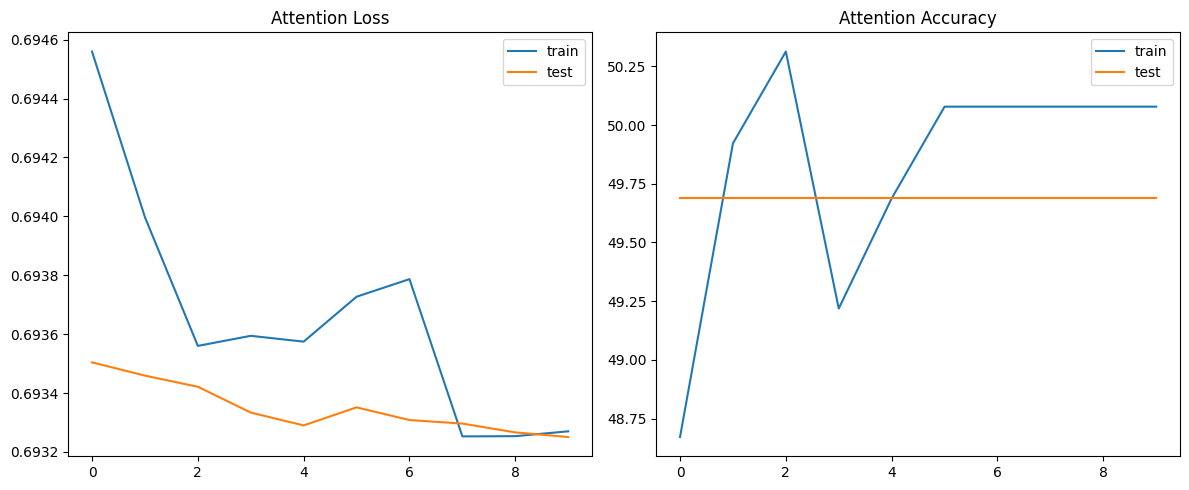

In [149]:
show_plots(train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr)

LSTM так же медленно обучается и дает плохие метрики

In [ ]:
model = ParfumClassifierLSTM(vocabulary_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr = train(model, criterion, optimizer, 40)

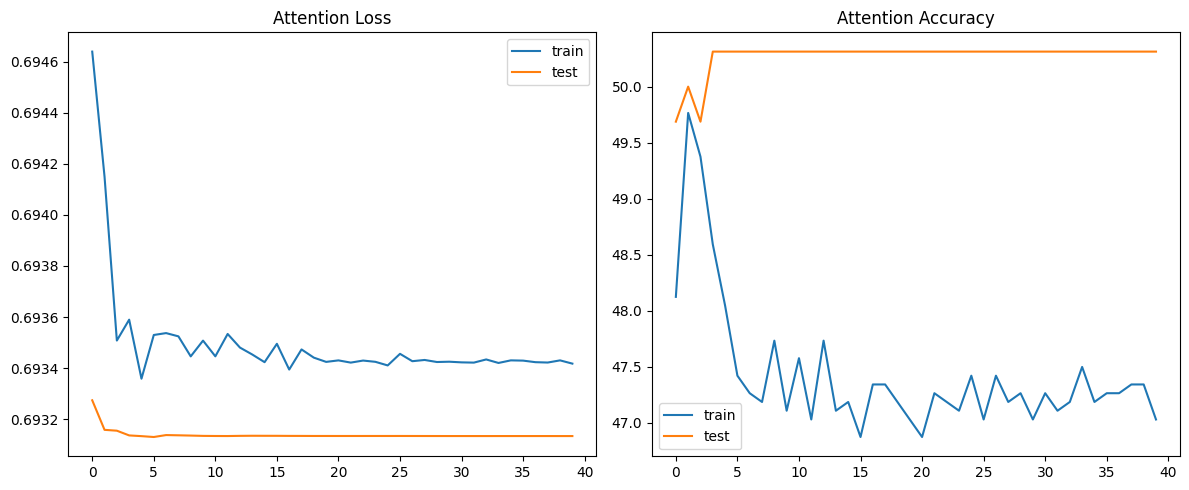

In [158]:
show_plots(train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr)

А простая модель только из линейных слоев дает хороший результат и быстро обучается. Поэтому я оставила ее

In [ ]:
model = ParfumClassifierLinear()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001)
train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr, embeddings_arr = train(model, criterion, optimizer, 1500)

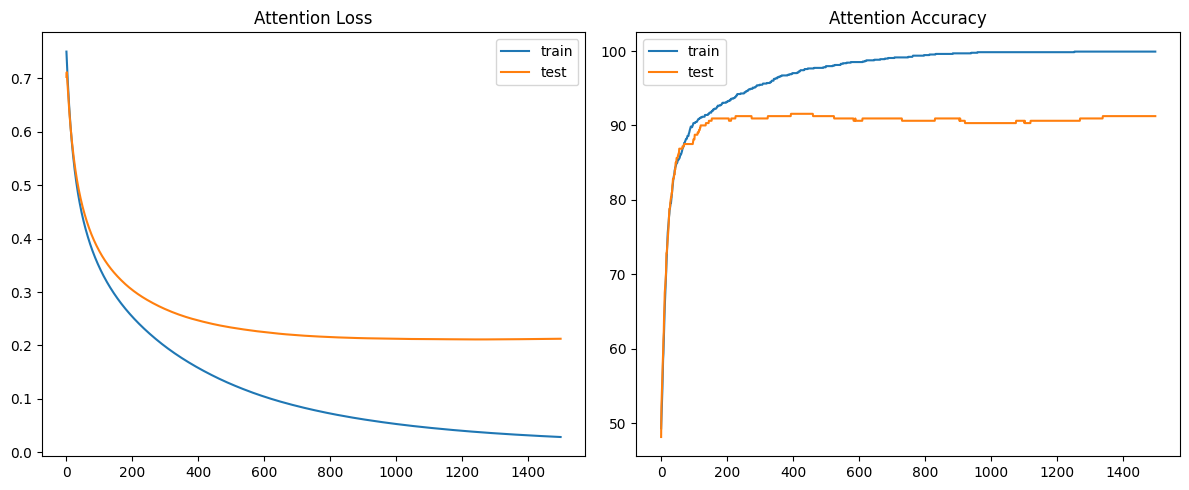

In [307]:
show_plots(train_loss_arr, test_loss_arr, train_accuracy_arr, test_accuracy_arr)

Accuracy: 91.2500%
ROC AUC: 0.9740
Precision: 0.8922
Recall: 0.9371
F1: 0.9141


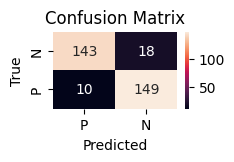

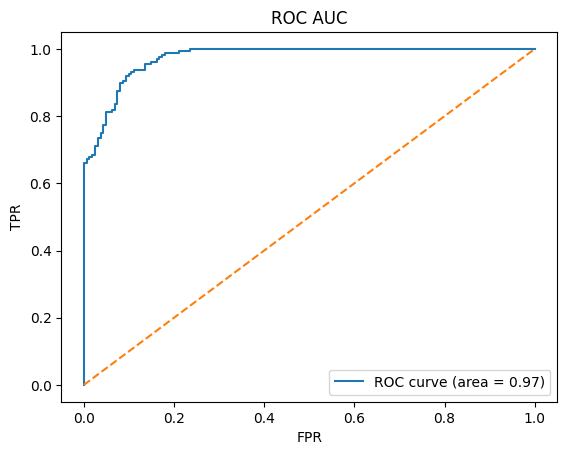

In [308]:
accuracy, avg_loss, all_outputs, all_labels = validate(model, test_loader, criterion)

predicted_labels = (all_outputs >= 0.5).astype(int)
precision = precision_score(all_labels, predicted_labels)
recall = recall_score(all_labels, predicted_labels)
f1 = f1_score(all_labels, predicted_labels)
roc_auc = roc_auc_score(all_labels, all_outputs)

print(f"Accuracy: {accuracy:.4f}%")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

cm = confusion_matrix(all_labels, predicted_labels)
plt.figure(figsize=(2, 1))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['P', 'N'], yticklabels=['N', 'P'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')


fpr, tpr, _ = roc_curve(all_labels, all_outputs)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC AUC')
plt.legend()
plt.show()


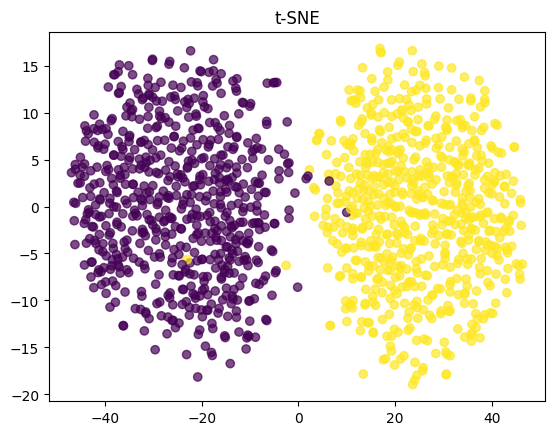

In [309]:
embeddings = np.array(embeddings_arr)
labels = y_train

tsne = TSNE(n_components=2, random_state=42)
data_2d = tsne.fit_transform(embeddings)

scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, alpha=0.7)

plt.title('t-SNE')
plt.show()